In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("crop_fertilizer_recommendation_dataset.csv")
df.sample(3)

,N,P,K,temperature,humidity,ph,rainfall,label,fertilizer,N_status,P_status,K_status,recommendation_note
313,25,60,22,21.631491,21.179197,5.887263,134.364995,kidneybeans,Urea (Nitrogen rich fertilizer),Low,Normal,Low,Based on NPK + climate conditions
1010,118,88,52,28.650039,82.687525,5.843163,98.750844,banana,Balanced NPK (14-14-14),High,Normal,Normal,Based on NPK + climate conditions
1640,1,30,10,11.899257,91.346638,7.291406,103.577147,orange,Balanced NPK (10-26-26),Low,Low,Low,Based on NPK + climate conditions


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   N                    2200 non-null   int64  
 1   P                    2200 non-null   int64  
 2   K                    2200 non-null   int64  
 3   temperature          2200 non-null   float64
 4   humidity             2200 non-null   float64
 5   ph                   2200 non-null   float64
 6   rainfall             2200 non-null   float64
 7   label                2200 non-null   object 
 8   fertilizer           2200 non-null   object 
 9   N_status             2200 non-null   object 
 10  P_status             2200 non-null   object 
 11  K_status             2200 non-null   object 
 12  recommendation_note  2200 non-null   object 
dtypes: float64(4), int64(3), object(6)
memory usage: 223.6+ KB


In [43]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'fertilizer'],
      dtype='object')

In [14]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
df.shape

(2200, 13)

In [7]:
df.dtypes

N                        int64
P                        int64
K                        int64
temperature            float64
humidity               float64
ph                     float64
rainfall               float64
label                   object
fertilizer              object
N_status                object
P_status                object
K_status                object
recommendation_note     object
dtype: object

In [8]:
df.isna().sum()

N                      0
P                      0
K                      0
temperature            0
humidity               0
ph                     0
rainfall               0
label                  0
fertilizer             0
N_status               0
P_status               0
K_status               0
recommendation_note    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["fertilizer"].value_counts()

fertilizer
Urea (Nitrogen rich fertilizer)    914
Balanced NPK (10-26-26)            378
DAP (Diammonium Phosphate)         371
MOP (Muriate of Potash)            274
Balanced NPK (14-14-14)            263
Name: count, dtype: int64

In [24]:
# Drop unwanted columns
df = df.drop(
    columns=[
        'N_status',
        'P_status',
        'K_status',
        'recommendation_note'
    ]
)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,fertilizer
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,Balanced NPK (14-14-14)
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,Balanced NPK (14-14-14)
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,Balanced NPK (14-14-14)
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,DAP (Diammonium Phosphate)
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,Balanced NPK (14-14-14)


In [25]:
# Features
X = df.drop('fertilizer', axis=1)

# Target
y = df['fertilizer']

In [74]:
X.head(5)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [54]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

<h3>Data Preprocessing</h3>

<h4>Outlier Detection</h4>

In [17]:
def count_outliers_iqr(df, thresh=1.5):
    result = []
    for col in df.select_dtypes(include=['number']).columns:
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - thresh * IQR
        upper_bound = Q3 + thresh * IQR

        count = (
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ).sum()

        result.append([col, count])

    return pd.DataFrame(
        result,
        columns=["Column", "Outlier_Count"]
    )

In [18]:
outlier_report = count_outliers_iqr(df)
outlier_report

,Column,Outlier_Count
0,N,0
1,P,138
2,K,200
3,temperature,86
4,humidity,30
5,ph,57
6,rainfall,100


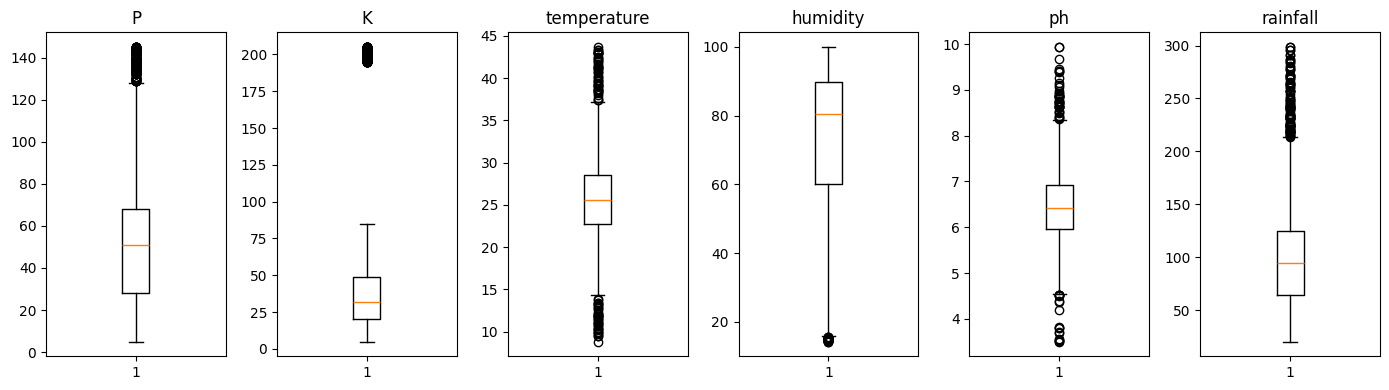

In [21]:
fig, axes = plt.subplots(1, 6, figsize=(14, 4))
for ax, col in zip(axes, ["P" , "K" , "temperature" , "humidity" , "ph" , "rainfall"]):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [23]:
def iqr_winsorization(df, thresh=1.5):
    df_out = df.copy()

    for col in df_out.select_dtypes(include=['number']).columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - thresh * IQR
        upper = Q3 + thresh * IQR

        df_out[col] = df_out[col].clip(lower, upper)

    return df_out

`Encoding Data`

In [28]:
from sklearn.preprocessing import LabelEncoder

le_crop = LabelEncoder()

X['label'] = le_crop.fit_transform(X['label'])

In [29]:
le_target = LabelEncoder()

y = le_target.fit_transform(y)

`Train - Test - Split`

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
print(X_train.shape)
print(X_test.shape)

(1760, 8)
(440, 8)


<h3>Model Selection</h3>

`Logistic Regression`

In [37]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_score = lr.score(X_test, y_test)

print("Logistic Regression:", lr_score)

Logistic Regression: 0.8613636363636363


`Decision Tree`

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_score = dt.score(X_test, y_test)

print("Decision Tree:", dt_score)

Decision Tree: 1.0


`Random Forest`

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_score = rf.score(X_test, y_test)

print("Random Forest:", rf_score)

Random Forest: 1.0


`KNN`

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_score = knn.score(X_test, y_test)

print("KNN:", knn_score)

KNN: 0.8818181818181818


`SVM`

In [41]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_score = svm.score(X_test, y_test)

print("SVM:", svm_score)

SVM: 0.8772727272727273


`Compare Models`

In [42]:
models = {
    'Logistic Regression': lr_score,
    'Decision Tree': dt_score,
    'Random Forest': rf_score,
    'KNN': knn_score,
    'SVM': svm_score
}

for model, score in models.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.8614
Decision Tree: 1.0000
Random Forest: 1.0000
KNN: 0.8818
SVM: 0.8773


`CROSS VALIDATION`

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

In [45]:
rf = RandomForestClassifier(
    random_state=42
)

In [46]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

In [48]:
print("Cross-validation scores:")
print(scores)

print("\nMean Accuracy:")
print(scores.mean())

Cross-validation scores:
[0.99772727 1.         0.94772727 0.86590909 1.        ]

Mean Accuracy:
0.9622727272727273


In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [57]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [58]:
dt_scores = cross_val_score(
    dt,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

In [59]:
print("Decision Tree Cross Validation Scores:")
print(dt_scores)

print("\nMean Accuracy:")
print(dt_scores.mean())


Decision Tree Cross Validation Scores:
[1.         1.         1.         0.86590909 1.        ]

Mean Accuracy:
0.9731818181818183


In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Random Forest CV Scores:")
print(rf_scores)

print("\nMean Accuracy:")
print(rf_scores.mean())

print("\nStandard Deviation:")
print(rf_scores.std())

Random Forest CV Scores:
[0.99772727 1.         0.94772727 0.86590909 1.        ]

Mean Accuracy:
0.9622727272727273

Standard Deviation:
0.05215599614506749


In [64]:


cv_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Mean CV Accuracy': [
        dt_scores.mean(),
        rf_scores.mean()
    ]
})

print(cv_results)

           Model  Mean CV Accuracy
0  Decision Tree          0.973182
1  Random Forest          0.962273


<h3>Decision Tree Classifier</h3>

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [66]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [67]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [68]:
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [69]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Score:
1.0


In [70]:
model = grid.best_estimator_

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [71]:
y_pred = model.predict(X_test)

<h4>Evaluation</h4>

In [72]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        55
           2       1.00      1.00      1.00        66
           3       1.00      1.00      1.00        53
           4       1.00      1.00      1.00       186

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440


Confusion Matrix:
[[ 80   0   0   0   0]
 [  0  55   0   0   0]
 [  0   0  66   0   0]
 [  0   0   0  53   0]
 [  0   0   0   0 186]]


In [73]:
# Take one sample
test_data = X_test.iloc[[0]]

print(test_data)

        N   P   K  temperature   humidity        ph   rainfall  label
1451  101  17  47    29.494014  94.729813  6.185053  26.308209     15


In [75]:
prediction = model.predict(test_data)

print("Encoded Prediction:", prediction)

Encoded Prediction: [2]


In [76]:
predicted_fertilizer = le_target.inverse_transform(prediction)

print("Predicted Fertilizer:")
print(predicted_fertilizer[0])

Predicted Fertilizer:
DAP (Diammonium Phosphate)


In [78]:
actual = le_target.inverse_transform(
    [y_test[0]]
)

print("Actual:", actual[0])
print("Predicted:", predicted_fertilizer[0])

Actual: DAP (Diammonium Phosphate)
Predicted: DAP (Diammonium Phosphate)


<h3>Save File</h3>

In [79]:
import pickle

In [80]:
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [81]:
with open('crop_encoder.pkl', 'wb') as f:
    pickle.dump(le_crop, f)

In [82]:
with open('fertilizer_encoder.pkl', 'wb') as f:
    pickle.dump(le_target, f)

In [83]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'crop_encoder.pkl', 'crop_fertilizer_recommendation_dataset.csv', 'decision_tree_model.pkl', 'fertilizer_encoder.pkl', 'train_model.ipynb', 'Untitled.ipynb']
